X (المساحات): [1. 2. 3. 4.]
Y (الأسعار): [300. 500. 700. 900.]

--- بدء عملية التدريب ---
Iteration    0: Cost 172203.94 | w:  17.5000, b:   6.0000
Iteration 1000: Cost     3.42 | w: 202.1760, b:  93.6023
Iteration 2000: Cost     0.17 | w: 200.4865, b:  98.5697
Iteration 3000: Cost     0.01 | w: 200.1088, b:  99.6802
Iteration 4000: Cost     0.00 | w: 200.0243, b:  99.9285
Iteration 5000: Cost     0.00 | w: 200.0054, b:  99.9840
Iteration 6000: Cost     0.00 | w: 200.0012, b:  99.9964
Iteration 7000: Cost     0.00 | w: 200.0003, b:  99.9992
Iteration 8000: Cost     0.00 | w: 200.0001, b:  99.9998
Iteration 9000: Cost     0.00 | w: 200.0000, b: 100.0000

القيم النهائية المثالية: w = 200.00, b = 100.00
السعر المتوقع لمنزل بمساحة 2500.0 قدم مربع هو: $600,000.00


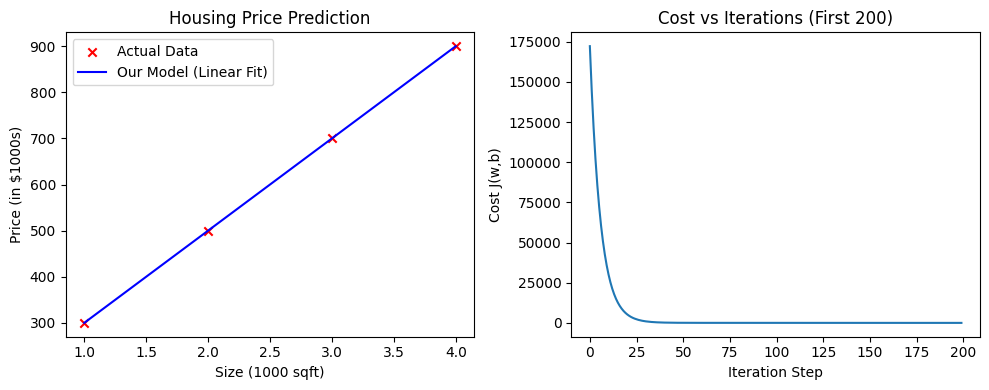

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. تجهيز البيانات (Training Data)
# x_train: مساحة البيت بـ 1000 قدم مربع
# y_train: سعر البيت بـ 100,000 دولار
# ---------------------------------------------------------
x_train = np.array([1.0, 2.0, 3.0, 4.0], dtype=np.float64)
y_train = np.array([300.0, 500.0, 700.0, 900.0], dtype=np.float64)

print(f"X (Space): {x_train}")
print(f"Y (Price): {y_train}")    
                   
                      
# ---------------------------------------------------------
# 2. حساب دالة التكلفة Cost Function J(w,b)
# ---------------------------------------------------------
def compute_cost(x, y, w, b):
    """
    تأخذ المدخلات والأوزان وترجع القيمة الإجمالية للخطأ J(w,b)
    """
    m = x.shape[0]
    cost_sum = 0.0

    for i in range(m):
        f_wb = w * x[i] + b  # التوقع
        cost = (f_wb - y[i]) ** 2  # مربع الخطأ
        cost_sum += cost

    total_cost = (1 / (2 * m)) * cost_sum
    return total_cost


# ---------------------------------------------------------
# 3. حساب المشتقات (Gradient Computation)
# ---------------------------------------------------------
def compute_gradient(x, y, w, b):
    """
    تحسب المشتقات الجزئية بالنسبة لـ w و b
    """
    m = x.shape[0]
    dj_dw = 0.0
    dj_db = 0.0

    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = f_wb - y[i]

        dj_dw += dj_dw_i
        dj_db += dj_db_i

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db


# ---------------------------------------------------------
# 4. خوارزمية الانحدار التدريجي (Gradient Descent)
# ---------------------------------------------------------
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_fn, gradient_fn):
    """
    يقوم بتحديث w و b للوصول للقيم المثالية
    """
    w = w_in
    b = b_in
    j_history = []

    for i in range(num_iters):
        # حساب المشتقات
        dj_dw, dj_db = gradient_fn(x, y, w, b)

        # التحديث المتزامن للأوزان (Simultaneous Update)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # حفظ التكلفة للمتابعة
        if i < 100000:  # تجنب استهلاك الذاكرة
            j_history.append(cost_fn(x, y, w, b))

        # طباعة التقدم كل 10% من التكرارات
        if i % (num_iters // 10) == 0:
            print(
                f"Iteration {i:4d}: Cost {j_history[-1]:8.2f} | w: {w:8.4f}, b: {b:8.4f}"
            )

    return w, b, j_history


# ---------------------------------------------------------
# 5. تشغيل التدريب (Training Step)
# ---------------------------------------------------------
w_init = 0.0
b_init = 0.0
iterations = 10000
alpha = 0.01

print("\n--- بدء عملية التدريب ---")
w_final, b_final, J_hist = gradient_descent(
    x_train, y_train, w_init, b_init, alpha, iterations, compute_cost, compute_gradient
)

print(f"\nالقيم النهائية المثالية: w = {w_final:.2f}, b = {b_final:.2f}")

# ---------------------------------------------------------
# 6. التنبؤ واختبار منزل بمساحة 2.5 (2500 قدم مربع)
# ---------------------------------------------------------
x_test = 2.5
predicted_price = w_final * x_test + b_final
print(
    f"السعر المتوقع لمنزل بمساحة {x_test * 1000} قدم مربع هو: ${predicted_price * 1000:,.2f}"
)

# ---------------------------------------------------------
# 7. رسم المحاكاة والـ Visualizations
# ---------------------------------------------------------
plt.figure(figsize=(10, 4))

# الرسم الأول: خط التناغم (Fit Line)
plt.subplot(1, 2, 1)
plt.scatter(x_train, y_train, marker="x", c="r", label="Actual Data")
plt.plot(x_train, w_final * x_train + b_final, label="Our Model (Linear Fit)", c="b")
plt.title("Housing Price Prediction")
plt.xlabel("Size (1000 sqft)")
plt.ylabel("Price (in $1000s)")
plt.legend()

# الرسم الثاني: انخفاض التكلفة عبر الزمن (Learning Curve)
plt.subplot(1, 2, 2)
plt.plot(J_hist[:200])
plt.title("Cost vs Iterations (First 200)")
plt.xlabel("Iteration Step")
plt.ylabel("Cost J(w,b)")

plt.tight_layout()
